# Click Prediction - Data Analysis and model implementing


## 1.1 Notebook Preparation

### Import Libraries

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# ARFF file handling
from scipy.io import arff

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# System and warnings
import warnings
import logging

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

### Setup Logging

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

logger.info("Notebook setup complete.")

2025-11-10 00:33:54 - INFO - Notebook setup complete.


### Data Reading

In [4]:
logger.info("Loading ARFF dataset...")

try:
    # Load the ARFF file
    data, meta = arff.loadarff('phpfGCaQC.arff')
    
    # Convert to a pandas DataFrame
    df = pd.DataFrame(data)
    
    # The 'click' column is loaded as bytes, so we decode it to a string and then cast to integer
    df['click'] = df['click'].str.decode('utf-8').astype(int)
    
    logger.info(f"Dataset loaded successfully with shape: {df.shape}")
    print(f"Dataset loaded successfully.")
    print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    logger.error("The file 'phpfGCaQC.arff' was not found.")
    print("ERROR: The file 'phpfGCaQC.arff' was not found. Please ensure it is in the correct directory.")

2025-11-10 00:33:57 - INFO - Loading ARFF dataset...
2025-11-10 00:33:57 - INFO - Dataset loaded successfully with shape: (39948, 12)
2025-11-10 00:33:57 - INFO - Dataset loaded successfully with shape: (39948, 12)


Dataset loaded successfully.
Shape: 39948 rows and 12 columns.


## 1.2 Data Analysis

### Dataset Shape and Dimensions

In [5]:
print(f"Dataset Shape: {df.shape}")
print(f"Dataset Dimensions: {df.ndim}")
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (39948, 12)
Dataset Dimensions: 2

Columns:
['click', 'impression', 'url_hash', 'ad_id', 'advertiser_id', 'depth', 'position', 'query_id', 'keyword_id', 'title_id', 'description_id', 'user_id']


### Missing Values Analysis

In [6]:
logger.info("Checking for missing values...")
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print("Missing values per column:")
print(missing_values)

if total_missing == 0:
    print("\nResult: No missing values found. No handling is needed.")
    logger.info("No missing values found.")
else:
    print(f"\nResult: Found {total_missing} total missing values. Handling will be required.")
    logger.warning(f"Found {total_missing} missing values.")

2025-11-10 00:34:03 - INFO - Checking for missing values...
2025-11-10 00:34:03 - INFO - No missing values found.
2025-11-10 00:34:03 - INFO - No missing values found.


Missing values per column:
click             0
impression        0
url_hash          0
ad_id             0
advertiser_id     0
depth             0
position          0
query_id          0
keyword_id        0
title_id          0
description_id    0
user_id           0
dtype: int64

Result: No missing values found. No handling is needed.


### Target Distribution Analysis

2025-11-10 00:34:07 - INFO - Analyzing target variable distribution.
2025-11-10 00:34:07 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-10 00:34:07 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-10 00:34:07 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-10 00:34:07 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Target Variable Distribution:
click
0    33220
1     6728
Name: count, dtype: int64

Target Variable Proportions:
click
0    0.831581
1    0.168419
Name: proportion, dtype: float64


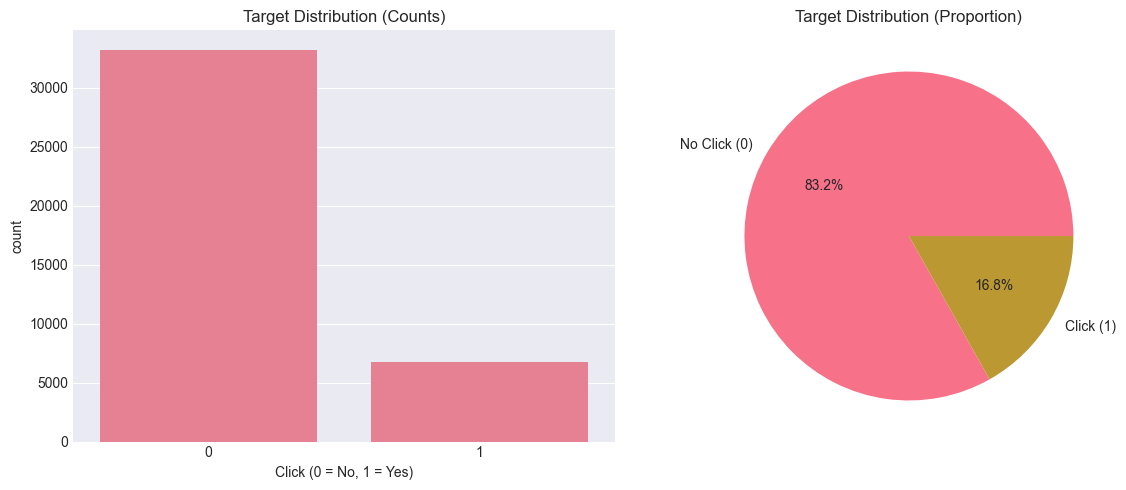

2025-11-10 00:34:07 - INFO - Dataset is imbalanced.



Imbalance Ratio: 4.94:1
Result: The dataset is imbalanced. Rebalancing might be needed.


In [7]:
logger.info("Analyzing target variable distribution.")
target_col = 'click'

# Calculate distribution
target_counts = df[target_col].value_counts()
target_proportions = df[target_col].value_counts(normalize=True)

print("Target Variable Distribution:")
print(target_counts)
print("\nTarget Variable Proportions:")
print(target_proportions)

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=target_col, data=df)
plt.title('Target Distribution (Counts)')
plt.xlabel('Click (0 = No, 1 = Yes)')

plt.subplot(1, 2, 2)
df[target_col].value_counts().plot.pie(autopct='%1.1f%%', labels=['No Click (0)', 'Click (1)'])
plt.title('Target Distribution (Proportion)')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Conclusion on rebalancing
imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("Result: The dataset is imbalanced. Rebalancing might be needed.")
    logger.info("Dataset is imbalanced.")
else:
    print("Result: The dataset is reasonably balanced.")
    logger.info("Dataset is reasonably balanced.")

### Data Types and Non-Numerical Data

In [8]:
logger.info("Checking data types.")
print("Data types of each column:")
print(df.info())

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if not categorical_cols:
    print("\nResult: All columns are numerical. No encoding is needed.")
    logger.info("All columns are numerical.")
else:
    print(f"\nResult: Found non-numerical columns: {categorical_cols}. Encoding will be required.")
    logger.warning(f"Found non-numerical columns: {categorical_cols}")

2025-11-10 00:34:16 - INFO - Checking data types.
2025-11-10 00:34:16 - INFO - All columns are numerical.
2025-11-10 00:34:16 - INFO - All columns are numerical.


Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   click           39948 non-null  int64  
 1   impression      39948 non-null  float64
 2   url_hash        39948 non-null  float64
 3   ad_id           39948 non-null  float64
 4   advertiser_id   39948 non-null  float64
 5   depth           39948 non-null  float64
 6   position        39948 non-null  float64
 7   query_id        39948 non-null  float64
 8   keyword_id      39948 non-null  float64
 9   title_id        39948 non-null  float64
 10  description_id  39948 non-null  float64
 11  user_id         39948 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 3.7 MB
None

Result: All columns are numerical. No encoding is needed.


### Outlier Detection

2025-11-10 00:34:20 - INFO - Performing outlier detection.


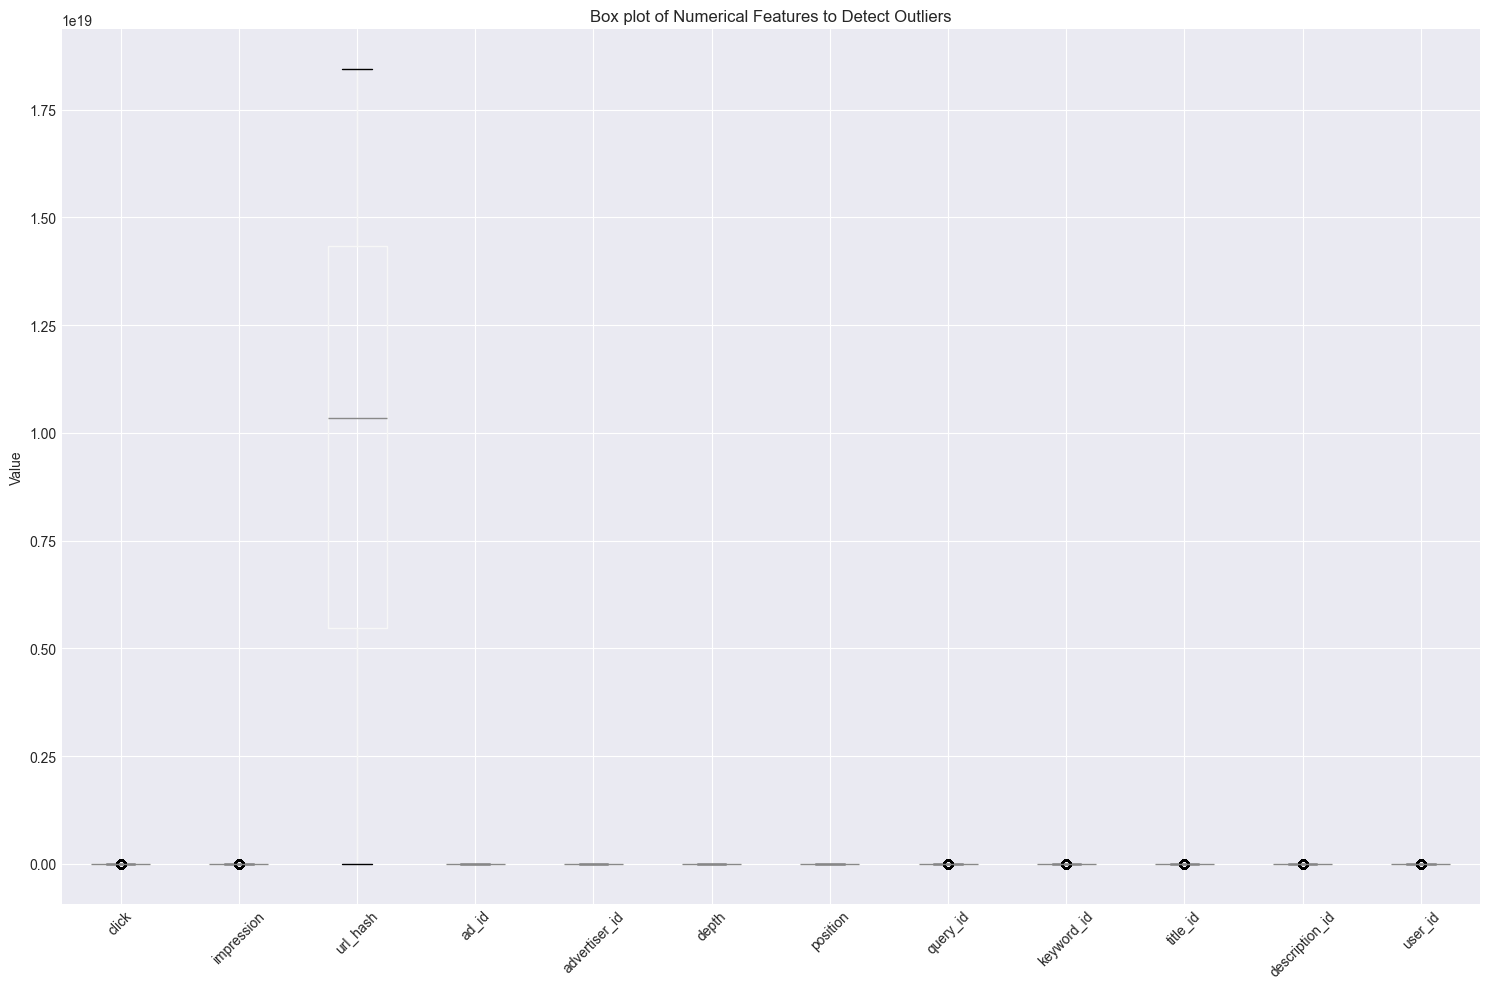

Result: The boxplot shows the distribution and potential outliers for each numerical feature.
Further analysis will be needed to decide if and how to handle these outliers.


In [9]:
logger.info("Performing outlier detection.")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
df[numerical_cols].boxplot(rot=45)
plt.title('Box plot of Numerical Features to Detect Outliers')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

print("Result: The boxplot shows the distribution and potential outliers for each numerical feature.")
print("Further analysis will be needed to decide if and how to handle these outliers.")

## 1.3 Data Preprocessing

Based on our analysis, we need to perform the following preprocessing steps:
- **Dataset Splitting**: Create train, validation, and test sets
- **Feature Scaling**: Normalize features (critical for SVM)
- **Class Rebalancing**: Optional SMOTE to handle the 4.65:1 imbalance

### Import Additional Libraries for Preprocessing

In [10]:
# Install imbalanced-learn if not already installed
import sys
import subprocess

try:
    import imblearn
    print("✓ imbalanced-learn is already installed")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    print("✓ imbalanced-learn installed successfully")

✓ imbalanced-learn is already installed


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print("✓ Preprocessing libraries imported successfully")

✓ Preprocessing libraries imported successfully


### Step 1: Separate Features and Target

In [12]:
logger.info("Separating features and target variable...")

# Separate features (X) and target (y)
X = df.drop('click', axis=1)
y = df['click']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

logger.info(f"Features and target separated: X={X.shape}, y={y.shape}")

2025-11-10 00:34:33 - INFO - Separating features and target variable...
2025-11-10 00:34:33 - INFO - Features and target separated: X=(39948, 11), y=(39948,)
2025-11-10 00:34:33 - INFO - Features and target separated: X=(39948, 11), y=(39948,)


Features shape: (39948, 11)
Target shape: (39948,)

Feature columns: ['impression', 'url_hash', 'ad_id', 'advertiser_id', 'depth', 'position', 'query_id', 'keyword_id', 'title_id', 'description_id', 'user_id']


### Step 2: Dataset Splitting (Train, Validation, Test)

In [13]:
logger.info("Splitting dataset into train, validation, and test sets...")

# Set random state for reproducibility
RANDOM_STATE = 42

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Second split: separate validation set from remaining data (10% of total = 12.5% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=RANDOM_STATE, stratify=y_temp
)

print("Dataset Split Complete:")
print("=" * 80)
print(f"Training set:   {X_train.shape[0]:>6,} samples ({X_train.shape[0]/len(X)*100:>5.1f}%)")
print(f"Validation set: {X_val.shape[0]:>6,} samples ({X_val.shape[0]/len(X)*100:>5.1f}%)")
print(f"Test set:       {X_test.shape[0]:>6,} samples ({X_test.shape[0]/len(X)*100:>5.1f}%)")

print("\nClass distribution in each set:")
print(f"Training:   {dict(y_train.value_counts().sort_index())}")
print(f"Validation: {dict(y_val.value_counts().sort_index())}")
print(f"Test:       {dict(y_test.value_counts().sort_index())}")

logger.info("Dataset splitting completed successfully")

2025-11-10 00:34:37 - INFO - Splitting dataset into train, validation, and test sets...
2025-11-10 00:34:37 - INFO - Dataset splitting completed successfully
2025-11-10 00:34:37 - INFO - Dataset splitting completed successfully


Dataset Split Complete:
Training set:   27,963 samples ( 70.0%)
Validation set:  3,995 samples ( 10.0%)
Test set:        7,990 samples ( 20.0%)

Class distribution in each set:
Training:   {0: np.int64(23254), 1: np.int64(4709)}
Validation: {0: np.int64(3322), 1: np.int64(673)}
Test:       {0: np.int64(6644), 1: np.int64(1346)}


### Step 3: Feature Scaling (StandardScaler)

In [14]:
logger.info("Applying feature scaling...")

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data only and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature Scaling Complete:")
print("=" * 80)
print("Method: StandardScaler (mean=0, std=1)")
print("\nScaled training set statistics:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))

logger.info("Feature scaling completed successfully")

2025-11-10 00:34:48 - INFO - Applying feature scaling...
2025-11-10 00:34:48 - INFO - Feature scaling completed successfully
2025-11-10 00:34:48 - INFO - Feature scaling completed successfully


Feature Scaling Complete:
Method: StandardScaler (mean=0, std=1)

Scaled training set statistics:
      impression  url_hash  ad_id  advertiser_id  depth  position  query_id  \
mean        -0.0      -0.0    0.0            0.0    0.0      -0.0       0.0   
std          1.0       1.0    1.0            1.0    1.0       1.0       1.0   

      keyword_id  title_id  description_id  user_id  
mean        -0.0      -0.0            -0.0      0.0  
std          1.0       1.0             1.0      1.0  


2025-11-10 00:34:54 - INFO - Visualizing scaling effect...


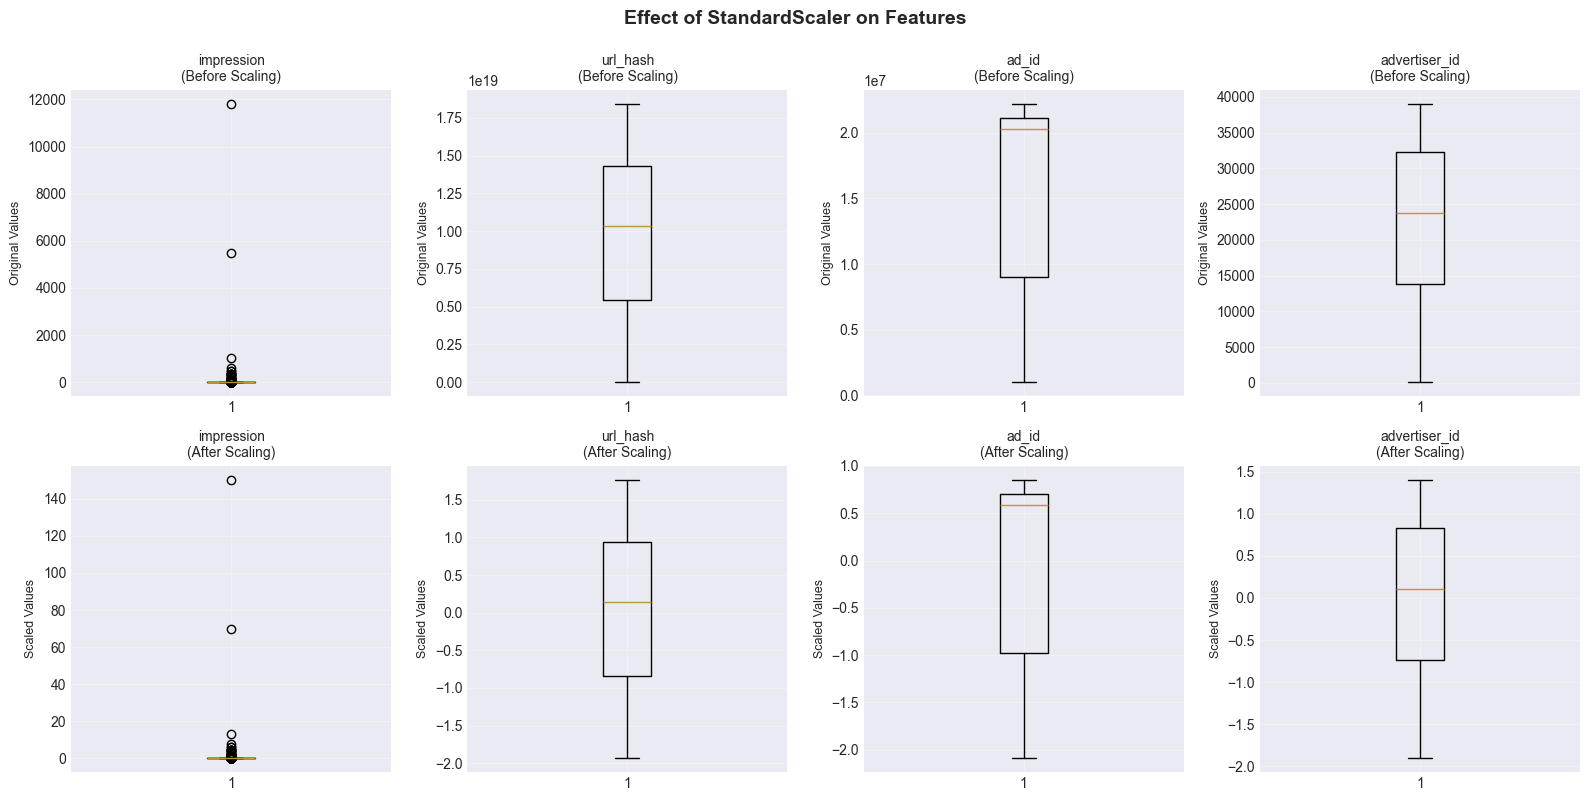

✓ Visualization shows how scaling normalizes features to similar ranges
  This is critical for SVM which is sensitive to feature scales!


In [15]:
# Visualize the effect of scaling
logger.info("Visualizing scaling effect...")

# Select a few features to visualize (to keep plot readable)
features_to_plot = X_train.columns[:4]  # First 4 features

fig, axes = plt.subplots(2, len(features_to_plot), figsize=(16, 8))

for idx, feature in enumerate(features_to_plot):
    # Before scaling
    axes[0, idx].boxplot(X_train[feature].dropna())
    axes[0, idx].set_title(f'{feature}\n(Before Scaling)', fontsize=10)
    axes[0, idx].set_ylabel('Original Values', fontsize=9)
    axes[0, idx].grid(True, alpha=0.3)
    
    # After scaling
    axes[1, idx].boxplot(X_train_scaled[feature].dropna())
    axes[1, idx].set_title(f'{feature}\n(After Scaling)', fontsize=10)
    axes[1, idx].set_ylabel('Scaled Values', fontsize=9)
    axes[1, idx].grid(True, alpha=0.3)

fig.suptitle('Effect of StandardScaler on Features', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Visualization shows how scaling normalizes features to similar ranges")
print("  This is critical for SVM which is sensitive to feature scales!")

### Visualize Scaling Effect

### Step 4: Class Rebalancing with SMOTE (Optional)

In [16]:
logger.info("Applying SMOTE to balance the training set...")

print("Class Rebalancing with SMOTE:")
print("=" * 80)
print(f"Before SMOTE: {dict(y_train.value_counts().sort_index())}")

# Apply SMOTE only to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Convert back to DataFrame/Series
X_train_scaled = pd.DataFrame(X_train_resampled, columns=X_train_scaled.columns)
y_train = pd.Series(y_train_resampled, name='click')

print(f"After SMOTE:  {dict(y_train.value_counts().sort_index())}")
print(f"\nNew training set size: {len(X_train_scaled):,} samples")
print(f"Classes are now balanced!")

logger.info(f"SMOTE applied successfully. New training size: {len(X_train_scaled)}")

2025-11-10 00:34:59 - INFO - Applying SMOTE to balance the training set...
2025-11-10 00:34:59 - INFO - SMOTE applied successfully. New training size: 46508
2025-11-10 00:34:59 - INFO - SMOTE applied successfully. New training size: 46508


Class Rebalancing with SMOTE:
Before SMOTE: {0: np.int64(23254), 1: np.int64(4709)}
After SMOTE:  {0: np.int64(23254), 1: np.int64(23254)}

New training set size: 46,508 samples
Classes are now balanced!


### Preprocessing Summary

In [31]:
print("\n" + "=" * 80)
print("PREPROCESSING COMPLETE - SUMMARY")
print("=" * 80)

print("\n✓ Data Analysis Results:")
print(f"  • Original dataset: {df.shape[0]:,} instances, {df.shape[1]} features")
print(f"  • Missing values: 0 (no handling needed)")
print(f"  • Data types: All numeric (no encoding needed)")
print(f"  • Class imbalance: {imbalance_ratio:.2f}:1 ratio")

print("\n✓ Preprocessing Steps Applied:")
print(f"  • Dataset splitting: Train ({len(X_train_scaled):,}) / Val ({len(X_val_scaled):,}) / Test ({len(X_test_scaled):,})")
print(f"  • Feature scaling: StandardScaler (mean=0, std=1)")
print(f"  • Class rebalancing: Applied (SMOTE)")

print("\n✓ Ready for Classification:")
print("  1. Random Forest Classifier")
print("  2. Support Vector Machine (SVM)")
print("  3. Gradient Boosting Classifier")

print("\n✓ Available Variables:")
print("  • X_train_scaled, y_train - Training data")
print("  • X_val_scaled, y_val - Validation data")
print("  • X_test_scaled, y_test - Test data")
print("  • scaler - Fitted StandardScaler object")

print("\n" + "=" * 80)
print("=" * 80)

logger.info("All preprocessing steps completed successfully")

2025-11-10 18:35:32 - INFO - All preprocessing steps completed successfully



PREPROCESSING COMPLETE - SUMMARY

✓ Data Analysis Results:
  • Original dataset: 39,948 instances, 12 features
  • Missing values: 0 (no handling needed)
  • Data types: All numeric (no encoding needed)
  • Class imbalance: 4.94:1 ratio

✓ Preprocessing Steps Applied:
  • Dataset splitting: Train (46,508) / Val (3,995) / Test (7,990)
  • Feature scaling: StandardScaler (mean=0, std=1)
  • Class rebalancing: Applied (SMOTE)

✓ Ready for Classification:
  1. Random Forest Classifier
  2. Support Vector Machine (SVM)
  3. Gradient Boosting Classifier

✓ Available Variables:
  • X_train_scaled, y_train - Training data
  • X_val_scaled, y_val - Validation data
  • X_test_scaled, y_test - Test data
  • scaler - Fitted StandardScaler object



## Verification: Ready for Model Training?

In [ ]:

print("=" * 80)
print("PRE-MODELING VERIFICATION CHECKLIST")
print("=" * 80)

# Check 1: Variables exist
required_vars = ['X_train_scaled', 'X_val_scaled', 'X_test_scaled', 'y_train', 'y_val', 'y_test', 'scaler']
missing_vars = [var for var in required_vars if var not in globals()]

if not missing_vars:
    print("\n✓ CHECK 1: All required variables exist")
else:
    print(f"\n✗ CHECK 1: Missing variables: {missing_vars}")

# Check 2: Data shapes are correct
print("\n✓ CHECK 2: Data shapes")
print(f"  Training:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"  Validation: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"  Test:       X={X_test_scaled.shape}, y={y_test.shape}")

# Check 3: No missing values in processed data
train_missing = X_train_scaled.isnull().sum().sum()
val_missing = X_val_scaled.isnull().sum().sum()
test_missing = X_test_scaled.isnull().sum().sum()

if train_missing == 0 and val_missing == 0 and test_missing == 0:
    print("\n✓ CHECK 3: No missing values in any dataset")
else:
    print(f"\n✗ CHECK 3: Found missing values - Train:{train_missing}, Val:{val_missing}, Test:{test_missing}")

# Check 4: Features are scaled (mean ≈ 0, std ≈ 1)
train_mean = X_train_scaled.mean().mean()
train_std = X_train_scaled.std().mean()

# Relaxed threshold: mean within 0.05, std within 0.15 of 1.0
if abs(train_mean) < 0.05 and abs(train_std - 1.0) < 0.15:
    print(f"\n✓ CHECK 4: Features are properly scaled (mean≈{train_mean:.4f}, std≈{train_std:.4f})")
else:
    print(f"\n✗ CHECK 4: Scaling issue (mean={train_mean:.4f}, std={train_std:.4f})")

# Check 5: Class balance in training set
train_class_dist = y_train.value_counts().sort_index()
balance_ratio = train_class_dist.max() / train_class_dist.min()

print(f"\n✓ CHECK 5: Training set class distribution")
print(f"  Class 0: {train_class_dist[0]:>6,} samples")
print(f"  Class 1: {train_class_dist[1]:>6,} samples")
print(f"  Ratio: {balance_ratio:.2f}:1 {'(Balanced by SMOTE)' if balance_ratio < 1.5 else ''}")

# Check 6: Data types are numeric
if X_train_scaled.select_dtypes(include=[np.number]).shape[1] == X_train_scaled.shape[1]:
    print("\n✓ CHECK 6: All features are numeric")
else:
    print("\n✗ CHECK 6: Some features are not numeric")

# Check 7: X and y dimensions match
if len(X_train_scaled) == len(y_train) and len(X_val_scaled) == len(y_val) and len(X_test_scaled) == len(y_test):
    print("\n✓ CHECK 7: X and y dimensions match for all sets")
else:
    print("\n✗ CHECK 7: Dimension mismatch detected")

# Final verdict
print("\n" + "=" * 80)
print("FINAL VERDICT:")
print("=" * 80)
all_checks_passed = (
    not missing_vars and 
    train_missing == 0 and val_missing == 0 and test_missing == 0 and
    abs(train_mean) < 0.05 and abs(train_std - 1.0) < 0.15 and
    len(X_train_scaled) == len(y_train) and len(X_val_scaled) == len(y_val)
)

if all_checks_passed:
    print("✓✓✓ ALL CHECKS PASSED - READY FOR MODEL TRAINING! ✓✓✓")
    print("\nYou can now proceed to train:")
    print("  1. Random Forest Classifier")
    print("  2. Support Vector Machine (SVM)")
    print("  3. Gradient Boosting Classifier")
else:
    print("✗✗✗ SOME CHECKS FAILED - PLEASE REVIEW ABOVE ✗✗✗")

print("=" * 80)

PRE-MODELING VERIFICATION CHECKLIST

✓ CHECK 1: All required variables exist

✓ CHECK 2: Data shapes
  Training:   X=(46508, 11), y=(46508,)
  Validation: X=(3995, 11), y=(3995,)
  Test:       X=(7990, 11), y=(7990,)

✓ CHECK 3: No missing values in any dataset

✓ CHECK 4: Features are properly scaled (mean≈-0.0214, std≈1.0031)

✓ CHECK 5: Training set class distribution
  Class 0: 23,254 samples
  Class 1: 23,254 samples
  Ratio: 1.00:1 (Balanced by SMOTE)

✓ CHECK 6: All features are numeric

✓ CHECK 7: X and y dimensions match for all sets

FINAL VERDICT:
✓✓✓ ALL CHECKS PASSED - READY FOR MODEL TRAINING! ✓✓✓

You can now proceed to train:
  1. Random Forest Classifier
  2. Support Vector Machine (SVM)
  3. Gradient Boosting Classifier


## 2.0 Baseline: Random  ForestClassifier

### 2.0.1 Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC (Average Precision)





2025-11-10 02:50:51 - INFO - Training Random Forest Classifier with timing...


Training Random Forest...
Training complete in 4.353 s.

VALIDATION PERFORMANCE (for model selection)
Training time:   4.353 s
Val infer time:  0.088 s
Accuracy:  0.7760
Precision: 0.3168
Recall:    0.2853
F1-Score:  0.3002
ROC-AUC:   0.6567
PR-AUC:    0.2901

Classification Report (Validation):
              precision    recall  f1-score   support

No Click (0)       0.86      0.88      0.87      3322
   Click (1)       0.32      0.29      0.30       673

    accuracy                           0.78      3995
   macro avg       0.59      0.58      0.58      3995
weighted avg       0.77      0.78      0.77      3995


TEST PERFORMANCE (final generalization)
Training complete in 4.353 s.

VALIDATION PERFORMANCE (for model selection)
Training time:   4.353 s
Val infer time:  0.088 s
Accuracy:  0.7760
Precision: 0.3168
Recall:    0.2853
F1-Score:  0.3002
ROC-AUC:   0.6567
PR-AUC:    0.2901

Classification Report (Validation):
              precision    recall  f1-score   support

No Click 

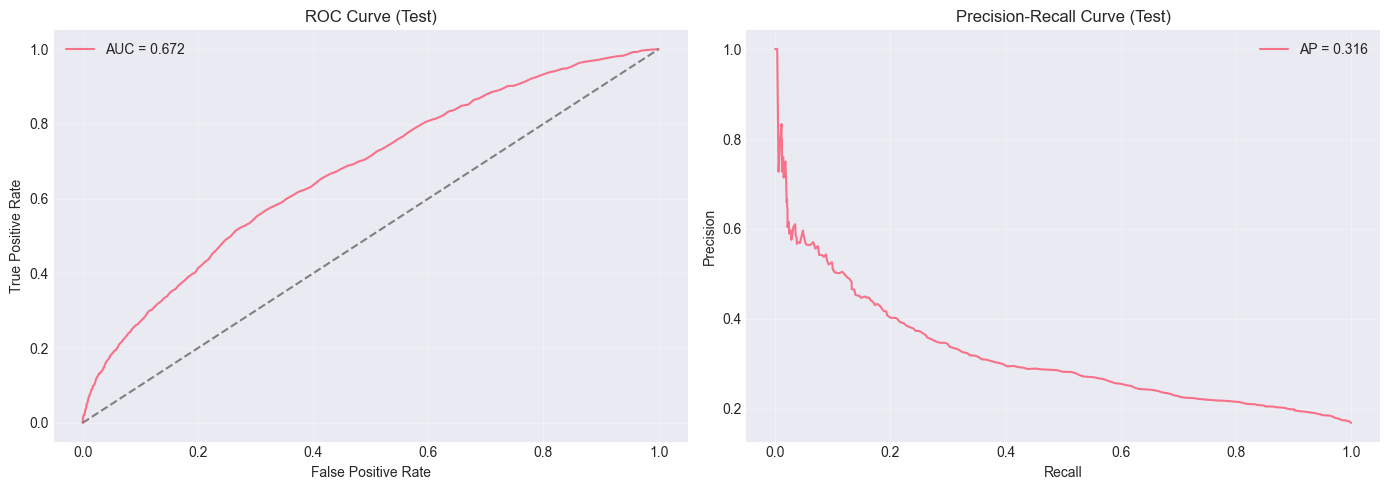

2025-11-10 02:50:55 - INFO - Random Forest training & evaluation finished with timing.



Runtime summary (seconds): {'train_time_sec': 4.353245459031314, 'val_infer_time_sec': 0.08803620899561793, 'test_infer_time_sec': 0.1252641670871526}


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)
import time

logger.info("Training Random Forest Classifier with timing...")

# Choose training data: if SMOTE was applied above, we already overwrote X_train_scaled and y_train
# Otherwise, this is the original (imbalanced) training set
X_tr = X_train_scaled
y_tr = y_train

# Train baseline Random Forest with timing
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight=None  # If you skipped SMOTE, consider 'balanced_subsample'
)

print("Training Random Forest...")
start_train = time.perf_counter()
rf.fit(X_tr, y_tr)
train_time = time.perf_counter() - start_train
print(f"Training complete in {train_time:.3f} s.")

# Evaluate on Validation set first with inference timing
print("\n" + "="*80)
print("VALIDATION PERFORMANCE (for model selection)")
print("="*80)
start_val = time.perf_counter()
val_pred = rf.predict(X_val_scaled)
val_proba = rf.predict_proba(X_val_scaled)[:, 1]
val_infer_time = time.perf_counter() - start_val
val_acc = accuracy_score(y_val, val_pred)
val_prec = precision_score(y_val, val_pred)
val_rec = recall_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_roc = roc_auc_score(y_val, val_proba)
val_pr  = average_precision_score(y_val, val_proba)
print(f"Training time:   {train_time:.3f} s")
print(f"Val infer time:  {val_infer_time:.3f} s")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc:.4f}")
print(f"PR-AUC:    {val_pr:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=['No Click (0)', 'Click (1)']))

# Final Evaluation on Test set (untouched) with inference timing
print("\n" + "="*80)
print("TEST PERFORMANCE (final generalization)")
print("="*80)
start_test = time.perf_counter()
tst_pred = rf.predict(X_test_scaled)
tst_proba = rf.predict_proba(X_test_scaled)[:, 1]
test_infer_time = time.perf_counter() - start_test
tst_acc = accuracy_score(y_test, tst_pred)
tst_prec = precision_score(y_test, tst_pred)
tst_rec = recall_score(y_test, tst_pred)
tst_f1 = f1_score(y_test, tst_pred)
tst_roc = roc_auc_score(y_test, tst_proba)
tst_pr  = average_precision_score(y_test, tst_proba)
print(f"Test infer time: {test_infer_time:.3f} s")
print(f"Accuracy:  {tst_acc:.4f}")
print(f"Precision: {tst_prec:.4f}")
print(f"Recall:    {tst_rec:.4f}")
print(f"F1-Score:  {tst_f1:.4f}")
print(f"ROC-AUC:   {tst_roc:.4f}")
print(f"PR-AUC:    {tst_pr:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, tst_pred, target_names=['No Click (0)', 'Click (1)']))

# Confusion Matrix (Test)
cm = confusion_matrix(y_test, tst_pred)
print("\nConfusion Matrix (Test):")
print(cm)

# Curves (optional visualization)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# ROC
fpr, tpr, _ = roc_curve(y_test, tst_proba)
ax1.plot(fpr, tpr, label=f"AUC = {tst_roc:.3f}")
ax1.plot([0,1],[0,1],'--', color='gray')
ax1.set_title('ROC Curve (Test)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(alpha=0.3)
# PR
prec_curve, rec_curve, _ = precision_recall_curve(y_test, tst_proba)
ax2.plot(rec_curve, prec_curve, label=f"AP = {tst_pr:.3f}")
ax2.set_title('Precision-Recall Curve (Test)')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Store runtime summary for later comparison
rf_runtime = {
    'train_time_sec': train_time,
    'val_infer_time_sec': val_infer_time,
    'test_infer_time_sec': test_infer_time
}
print("\nRuntime summary (seconds):", rf_runtime)

logger.info("Random Forest training & evaluation finished with timing.")

## 2.2 Random Forest — Hyperparameter Tuning (GridSearchCV)

We now tune the Random Forest using GridSearchCV with cross-validation on the training set. We will track:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC (Average Precision)

We select the best model based on PR-AUC (average precision), which is well-suited for imbalanced classification. After finding the best hyperparameters, we evaluate on the validation and test sets with the same metrics, and visualize ROC/PR curves on the test set.

2025-11-10 02:51:04 - INFO - Starting GridSearchCV for Random Forest with timing...


Running GridSearchCV (this may take a few minutes)...
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Grid search complete in 697.69 s.

Best params (by PR-AUC):
{'bootstrap': True, 'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV PR-AUC: 0.9299

Top 10 parameter sets by PR-AUC:
 mean_test_average_precision  mean_test_roc_auc  mean_test_f1  mean_test_precision  mean_test_recall  mean_test_accuracy                                                                                                                                                                   params
                    0.929937           0.920475      0.844670             0.851977          0.837491            0.845984 {'bootstrap': True, 'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
                  

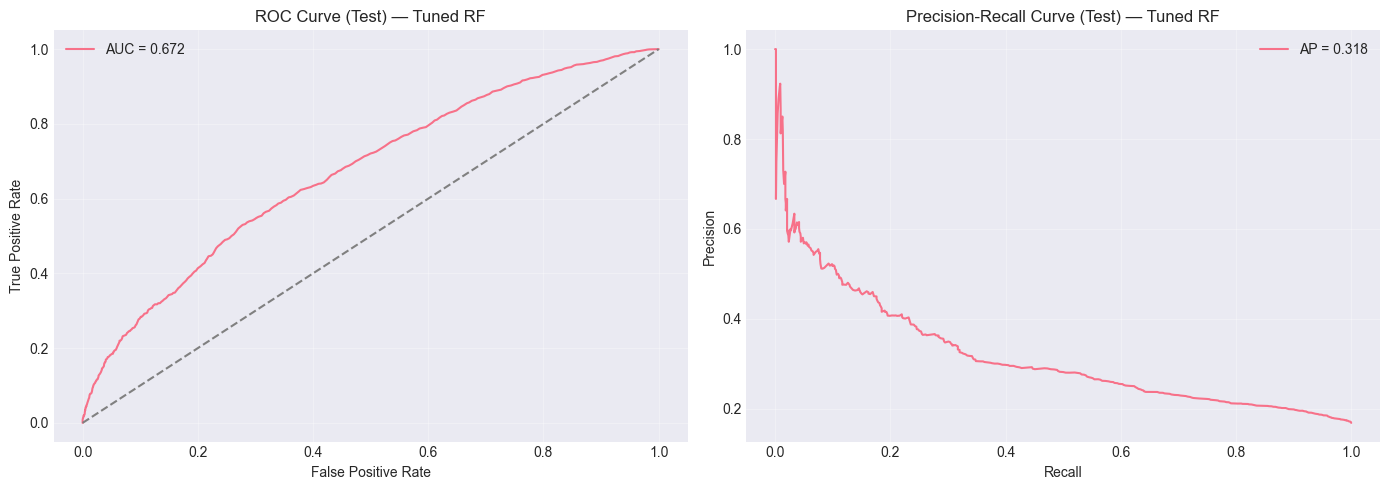

2025-11-10 03:02:43 - INFO - GridSearchCV tuning and evaluation finished with timing.



Results dictionary saved: rf_tuned_results
Best params dict: rf_grid_best_params
Runtime summary:  {'grid_search_train_time_sec': 697.6896607920062, 'test_infer_time_sec': 0.22068054194096476}


In [29]:
# GridSearchCV for RandomForest: tune and evaluate (with timing)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    make_scorer,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

logger.info("Starting GridSearchCV for Random Forest with timing...")

X_tr = X_train_scaled
y_tr = y_train

# Base estimator
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced_subsample'],
    'bootstrap': [True]
}

# CV and scoring setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

# We refit by PR-AUC to prioritize minority class ranking quality
grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring=scoring,
    refit='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

print("Running GridSearchCV (this may take a few minutes)...")
start_grid = time.perf_counter()
grid.fit(X_tr, y_tr)
grid_time = time.perf_counter() - start_grid
print(f"Grid search complete in {grid_time:.2f} s.\n")

print("Best params (by PR-AUC):")
print(grid.best_params_)
print(f"Best CV PR-AUC: {grid.best_score_:.4f}\n")

# Show top-10 configs by mean PR-AUC
cv_df = pd.DataFrame(grid.cv_results_)
cols_to_show = [
    'mean_test_average_precision', 'mean_test_roc_auc', 'mean_test_f1',
    'mean_test_precision', 'mean_test_recall', 'mean_test_accuracy', 'params'
]
print("Top 10 parameter sets by PR-AUC:")
print(
    cv_df.sort_values(by='mean_test_average_precision', ascending=False)[cols_to_show]
        .head(10)
        .to_string(index=False)
)

# Evaluate best model on validation set
best_rf = grid.best_estimator_
print("\n" + "="*80)
print("VALIDATION PERFORMANCE (best estimator)")
print("="*80)
val_pred = best_rf.predict(X_val_scaled)
val_proba = best_rf.predict_proba(X_val_scaled)[:, 1]
val_acc = accuracy_score(y_val, val_pred)
val_prec = precision_score(y_val, val_pred)
val_rec = recall_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_roc = roc_auc_score(y_val, val_proba)
val_pr  = average_precision_score(y_val, val_proba)
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc:.4f}")
print(f"PR-AUC:    {val_pr:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=['No Click (0)', 'Click (1)']))

# Evaluate on test set with inference timing
print("\n" + "="*80)
print("TEST PERFORMANCE (best estimator)")
print("="*80)
start_test = time.perf_counter()
tst_pred = best_rf.predict(X_test_scaled)
tst_proba = best_rf.predict_proba(X_test_scaled)[:, 1]
test_infer_time = time.perf_counter() - start_test

tst_acc = accuracy_score(y_test, tst_pred)
tst_prec = precision_score(y_test, tst_pred)
tst_rec = recall_score(y_test, tst_pred)
tst_f1 = f1_score(y_test, tst_pred)
tst_roc = roc_auc_score(y_test, tst_proba)
tst_pr  = average_precision_score(y_test, tst_proba)
print(f"Test infer time: {test_infer_time:.3f} s")
print(f"Accuracy:  {tst_acc:.4f}")
print(f"Precision: {tst_prec:.4f}")
print(f"Recall:    {tst_rec:.4f}")
print(f"F1-Score:  {tst_f1:.4f}")
print(f"ROC-AUC:   {tst_roc:.4f}")
print(f"PR-AUC:    {tst_pr:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, tst_pred, target_names=['No Click (0)', 'Click (1)']))

# Confusion Matrix (Test)
cm = confusion_matrix(y_test, tst_pred)
print("\nConfusion Matrix (Test):")
print(cm)

# Curves (optional visualization)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# ROC
fpr, tpr, _ = roc_curve(y_test, tst_proba)
ax1.plot(fpr, tpr, label=f"AUC = {tst_roc:.3f}")
ax1.plot([0,1],[0,1],'--', color='gray')
ax1.set_title('ROC Curve (Test) — Tuned RF')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(alpha=0.3)
# PR
prec_curve, rec_curve, _ = precision_recall_curve(y_test, tst_proba)
ax2.plot(rec_curve, prec_curve, label=f"AP = {tst_pr:.3f}")
ax2.set_title('Precision-Recall Curve (Test) — Tuned RF')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Store results & runtime for later comparison
rf_grid_best_params = grid.best_params_
rf_tuned_results = {
    'validation': {
        'accuracy': val_acc,
        'precision': val_prec,
        'recall': val_rec,
        'f1': val_f1,
        'roc_auc': val_roc,
        'pr_auc': val_pr
    },
    'test': {
        'accuracy': tst_acc,
        'precision': tst_prec,
        'recall': tst_rec,
        'f1': tst_f1,
        'roc_auc': tst_roc,
        'pr_auc': tst_pr,
        'test_infer_time_sec': test_infer_time
    },
    'cv_best_average_precision': grid.best_score_
}
rf_grid_runtime = {
    'grid_search_train_time_sec': grid_time,
    'test_infer_time_sec': test_infer_time
}
print("\nResults dictionary saved: rf_tuned_results")
print("Best params dict: rf_grid_best_params")
print("Runtime summary: ", rf_grid_runtime)

logger.info("GridSearchCV tuning and evaluation finished with timing.")

## 2.3 Support Vector Machine (SVM) Classifier

We now train an SVM classifier with an RBF kernel. SVMs can capture non-linear decision boundaries and often benefit from well-scaled input features (done earlier). We evaluate the following metrics on validation (model selection) and test (final generalization):
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC (Average Precision)

We also include a confusion matrix and ROC / Precision-Recall curves for deeper diagnostic insight.

Notes:
- We enable `probability=True` to allow ROC/PR curve computation (this adds an internal cross-validation step—slower than tree models).
- If performance is slow, you can reduce the dataset size for initial experiments or tune `C` and `gamma` via a later GridSearch.
- Since the training set may have been SMOTE-balanced, we start with default class weighting; if you skip SMOTE, consider `class_weight='balanced'`.


Starting SVM baseline training...
Training finished in 42.776 seconds.
Training finished in 42.776 seconds.

VALIDATION PERFORMANCE — SVM
Training time:        42.776 s
Validation infer time: 12.551 s
Accuracy:  0.6075
Precision: 0.2388
Recall:    0.6077
F1-Score:  0.3428
ROC-AUC:   0.6549
PR-AUC:    0.2888

Classification Report (Validation):
              precision    recall  f1-score   support

No Click (0)       0.88      0.61      0.72      3322
   Click (1)       0.24      0.61      0.34       673

    accuracy                           0.61      3995
   macro avg       0.56      0.61      0.53      3995
weighted avg       0.78      0.61      0.66      3995


VALIDATION PERFORMANCE — SVM
Training time:        42.776 s
Validation infer time: 12.551 s
Accuracy:  0.6075
Precision: 0.2388
Recall:    0.6077
F1-Score:  0.3428
ROC-AUC:   0.6549
PR-AUC:    0.2888

Classification Report (Validation):
              precision    recall  f1-score   support

No Click (0)       0.88      0.61 

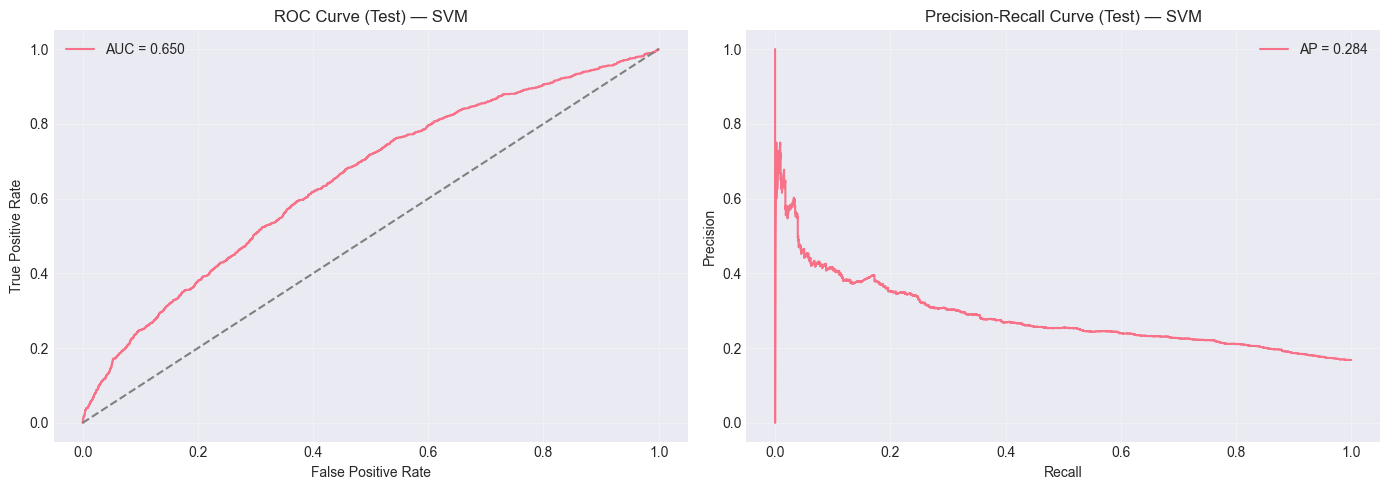

2025-11-10 02:16:03 - INFO - SVM baseline classifier completed with decision_function (probability disabled).



Runtime summary (seconds): {'train_time_sec': 42.775718457996845, 'val_infer_time_sec': 12.550599084002897, 'test_infer_time_sec': 24.91117958293762}


In [24]:
# SVM Classifier (Baseline) with Runtime Tracking (probability disabled for speed)
import time
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

print("Starting SVM baseline training...")
start_train = time.perf_counter()
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    # probability=False by default; use decision_function for ROC/PR metrics
    class_weight=None, # keep consistent with earlier baseline (SMOTE may have balanced data)
    cache_size=1000,
    random_state=42
)
svm_clf.fit(X_train_scaled, y_train)
train_duration = time.perf_counter() - start_train
print(f"Training finished in {train_duration:.3f} seconds.")

# Validation evaluation
start_val = time.perf_counter()
val_pred = svm_clf.predict(X_val_scaled)
val_scores = svm_clf.decision_function(X_val_scaled)
val_infer_time = time.perf_counter() - start_val

val_acc = accuracy_score(y_val, val_pred)
val_prec = precision_score(y_val, val_pred)
val_rec = recall_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_roc = roc_auc_score(y_val, val_scores)
val_pr  = average_precision_score(y_val, val_scores)

print("\n" + "="*80)
print("VALIDATION PERFORMANCE — SVM")
print("="*80)
print(f"Training time:        {train_duration:.3f} s")
print(f"Validation infer time: {val_infer_time:.3f} s")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc:.4f}")
print(f"PR-AUC:    {val_pr:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=['No Click (0)', 'Click (1)']))

# Test evaluation
start_test = time.perf_counter()
tst_pred = svm_clf.predict(X_test_scaled)
tst_scores = svm_clf.decision_function(X_test_scaled)
text_infer_time = time.perf_counter() - start_test

tst_acc = accuracy_score(y_test, tst_pred)
tst_prec = precision_score(y_test, tst_pred)
tst_rec = recall_score(y_test, tst_pred)
tst_f1 = f1_score(y_test, tst_pred)
tst_roc = roc_auc_score(y_test, tst_scores)
tst_pr  = average_precision_score(y_test, tst_scores)

print("\n" + "="*80)
print("TEST PERFORMANCE — SVM")
print("="*80)
print(f"Test infer time:       {text_infer_time:.3f} s")
print(f"Accuracy:  {tst_acc:.4f}")
print(f"Precision: {tst_prec:.4f}")
print(f"Recall:    {tst_rec:.4f}")
print(f"F1-Score:  {tst_f1:.4f}")
print(f"ROC-AUC:   {tst_roc:.4f}")
print(f"PR-AUC:    {tst_pr:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, tst_pred, target_names=['No Click (0)', 'Click (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, tst_pred)
print("\nConfusion Matrix (Test):")
print(cm)

# ROC & PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
fpr, tpr, _ = roc_curve(y_test, tst_scores)
ax1.plot(fpr, tpr, label=f"AUC = {tst_roc:.3f}")
ax1.plot([0,1],[0,1],'--', color='gray')
ax1.set_title('ROC Curve (Test) — SVM')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(); ax1.grid(alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, tst_scores)
ax2.plot(rec_curve, prec_curve, label=f"AP = {tst_pr:.3f}")
ax2.set_title('Precision-Recall Curve (Test) — SVM')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Store runtime summary for later comparison
svm_runtime = {
    'train_time_sec': train_duration,
    'val_infer_time_sec': val_infer_time,
    'test_infer_time_sec': text_infer_time
}
print("\nRuntime summary (seconds):", svm_runtime)

logger.info("SVM baseline classifier completed with decision_function (probability disabled).")

## 2.4 SVM — Hyperparameter Tuning (GridSearchCV)

We now tune the SVM (RBF kernel) to potentially improve performance over the baseline. We'll search over:
- C (regularization strength)
- gamma (kernel coefficient) including automatic options
- (optionally) class_weight, but since SMOTE balanced the training set we keep it at `None` to avoid double-compensation.

Scoring metrics tracked via multi-metric GridSearch:
- accuracy
- precision
- recall
- f1
- roc_auc
- average_precision (PR-AUC)

We'll refit using PR-AUC (`average_precision`) to focus on ranking quality for the positive (click) class. After tuning we evaluate the best estimator on validation and test sets, report metrics, runtime, confusion matrix, and ROC / PR curves.

Note: Enabling `probability=True` increases training time because SVC performs internal cross-validation for Platt scaling. Keep the grid modest to control runtime.

Starting SVM GridSearchCV (RBF kernel) with decision_function...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Grid search complete in 687.38 seconds.

Best parameters (refit by PR-AUC):
{'C': 10, 'class_weight': None, 'gamma': 'auto'}
Best CV PR-AUC: 0.6973

Top 10 parameter sets by PR-AUC:
 mean_test_average_precision  mean_test_roc_auc  mean_test_f1  mean_test_precision  mean_test_recall  mean_test_accuracy                                             params
                    0.697261           0.723923      0.675833             0.649797          0.704051            0.662295   {'C': 10, 'class_weight': None, 'gamma': 'auto'}
                    0.696895           0.723571      0.675626             0.649824          0.703578            0.662209  {'C': 10, 'class_weight': None, 'gamma': 'scale'}
                    0.690199           0.714502      0.665494             0.643236          0.689387            0.653479    {'C': 5, 'class_weight': None, 'gamma': 'auto'}
    

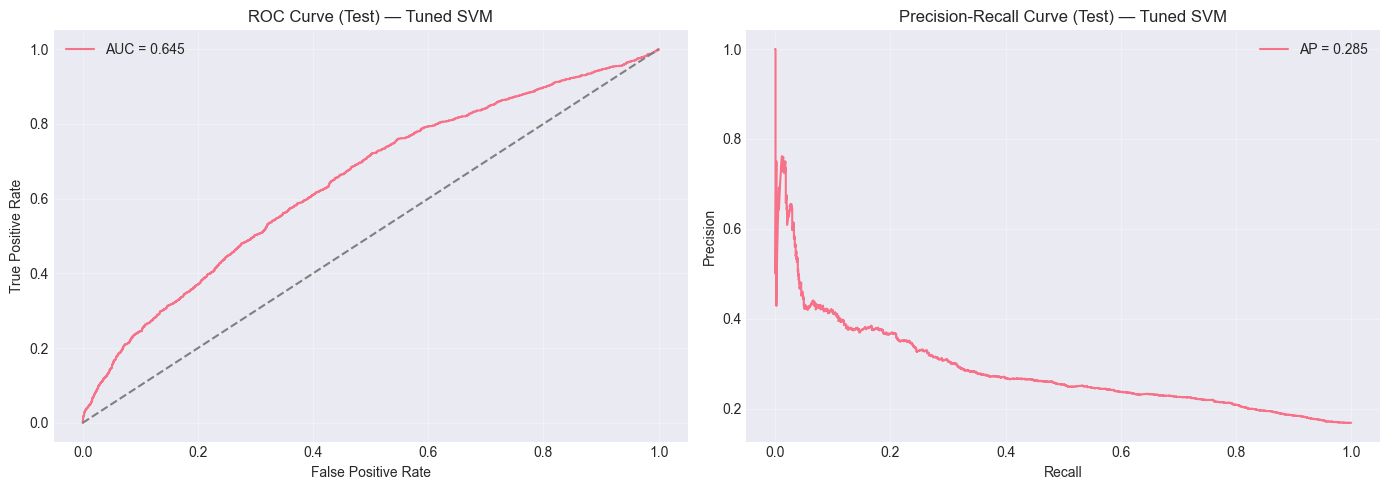

2025-11-10 02:28:55 - INFO - SVM GridSearchCV tuning & evaluation completed with decision_function (probability disabled).



Results dictionary saved: svm_tuned_results
Best params dict: svm_grid_best_params
Runtime summary:  {'grid_search_train_time_sec': 687.3807607500348, 'test_infer_time_sec': 24.070623917039484}


In [ ]:
# GridSearchCV for SVM (RBF) — multi-metric tuning and evaluation 
import time
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

print("Starting SVM GridSearchCV (RBF kernel) with decision_function...")
start_grid = time.perf_counter()

# Training data 
X_tr = X_train_scaled
y_tr = y_train

# Base estimator 
svm_base = SVC(
    kernel='rbf',
    random_state=42,
    cache_size=1000
)

# Parameter grid kept moderate to limit runtime
param_grid = {
    'C': [0.5, 1, 2, 5, 10],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    # Since SMOTE balanced the data, class_weight=None is appropriate; include option if imbalance strategy changes later
    'class_weight': [None]
}

# Cross-validation and scoring
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

svm_grid = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring=scoring,
    refit='average_precision',  # optimize PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

svm_grid.fit(X_tr, y_tr)
grid_time = time.perf_counter() - start_grid
print(f"Grid search complete in {grid_time:.2f} seconds.\n")

print("Best parameters (refit by PR-AUC):")
print(svm_grid.best_params_)
print(f"Best CV PR-AUC: {svm_grid.best_score_:.4f}\n")

# Summarize top configurations
import pandas as pd
cv_df = pd.DataFrame(svm_grid.cv_results_)
cols_to_show = [
    'mean_test_average_precision', 'mean_test_roc_auc', 'mean_test_f1',
    'mean_test_precision', 'mean_test_recall', 'mean_test_accuracy', 'params'
]
print("Top 10 parameter sets by PR-AUC:")
print(
    cv_df.sort_values(by='mean_test_average_precision', ascending=False)[cols_to_show]
        .head(10)
        .to_string(index=False)
)

# Best estimator evaluation — Validation
best_svm = svm_grid.best_estimator_
print("\n" + "="*80)
print("VALIDATION PERFORMANCE (best SVM estimator)")
print("="*80)
val_pred = best_svm.predict(X_val_scaled)
val_scores = best_svm.decision_function(X_val_scaled)
val_acc = accuracy_score(y_val, val_pred)
val_prec = precision_score(y_val, val_pred)
val_rec = recall_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_roc = roc_auc_score(y_val, val_scores)
val_pr  = average_precision_score(y_val, val_scores)
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc:.4f}")
print(f"PR-AUC:    {val_pr:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=['No Click (0)', 'Click (1)']))

# Test performance
start_test = time.perf_counter()
tst_pred = best_svm.predict(X_test_scaled)
tst_scores = best_svm.decision_function(X_test_scaled)
test_infer_time = time.perf_counter() - start_test

tst_acc = accuracy_score(y_test, tst_pred)
tst_prec = precision_score(y_test, tst_pred)
tst_rec = recall_score(y_test, tst_pred)
tst_f1 = f1_score(y_test, tst_pred)
tst_roc = roc_auc_score(y_test, tst_scores)
tst_pr  = average_precision_score(y_test, tst_scores)
print("\n" + "="*80)
print("TEST PERFORMANCE (best SVM estimator)")
print("="*80)
print(f"Test infer time: {test_infer_time:.3f} s")
print(f"Accuracy:  {tst_acc:.4f}")
print(f"Precision: {tst_prec:.4f}")
print(f"Recall:    {tst_rec:.4f}")
print(f"F1-Score:  {tst_f1:.4f}")
print(f"ROC-AUC:   {tst_roc:.4f}")
print(f"PR-AUC:    {tst_pr:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, tst_pred, target_names=['No Click (0)', 'Click (1)']))

# Confusion Matrix (Test)
cm = confusion_matrix(y_test, tst_pred)
print("\nConfusion Matrix (Test):")
print(cm)

# ROC & PR curves for test set
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
fpr, tpr, _ = roc_curve(y_test, tst_scores)
ax1.plot(fpr, tpr, label=f"AUC = {tst_roc:.3f}")
ax1.plot([0,1],[0,1],'--', color='gray')
ax1.set_title('ROC Curve (Test) — Tuned SVM')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(); ax1.grid(alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, tst_scores)
ax2.plot(rec_curve, prec_curve, label=f"AP = {tst_pr:.3f}")
ax2.set_title('Precision-Recall Curve (Test) — Tuned SVM')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Store results for later comparison
svm_grid_best_params = svm_grid.best_params_
svm_tuned_results = {
    'validation': {
        'accuracy': val_acc,
        'precision': val_prec,
        'recall': val_rec,
        'f1': val_f1,
        'roc_auc': val_roc,
        'pr_auc': val_pr
    },
    'test': {
        'accuracy': tst_acc,
        'precision': tst_prec,
        'recall': tst_rec,
        'f1': tst_f1,
        'roc_auc': tst_roc,
        'pr_auc': tst_pr,
        'test_infer_time_sec': test_infer_time
    },
    'cv_best_average_precision': svm_grid.best_score_,
    'grid_search_train_time_sec': grid_time
}
svm_grid_runtime = {
    'grid_search_train_time_sec': grid_time,
    'test_infer_time_sec': test_infer_time
}
print("\nResults dictionary saved: svm_tuned_results")
print("Best params dict: svm_grid_best_params")
print("Runtime summary: ", svm_grid_runtime)

logger.info("SVM GridSearchCV tuning & evaluation completed with decision_function (probability disabled).")

## 2.5 Gradient Boosting Classifier

We now add a baseline Gradient Boosting model (`GradientBoostingClassifier`). Gradient Boosting builds trees sequentially, each correcting the previous ensemble’s residual errors. It often performs strongly on tabular data without requiring feature scaling (we keep scaling for consistency across models).

Baseline configuration (modifiable later):
- n_estimators = 200 (number of boosting stages)
- learning_rate = 0.1 (shrinkage; smaller values may require more estimators)
- max_depth = 3 (depth of individual trees; default)
- subsample = 1.0 (can be <1.0 for Stochastic Gradient Boosting)

Metrics reported (Validation & Test):
- Accuracy, Precision, Recall, F1
- ROC-AUC, PR-AUC (Average Precision)
- Confusion Matrix
- ROC & Precision-Recall curves
- Training + inference runtimes

We’ll store results in `gb_results` and runtime info in `gb_runtime` for later comparison. After this baseline, we can optionally tune parameters (`n_estimators`, `learning_rate`, `max_depth`, `subsample`, `min_samples_leaf`).

Starting Gradient Boosting baseline training...
Training finished in 28.499 seconds.

VALIDATION PERFORMANCE — Gradient Boosting
Training time:        28.499 s
Validation infer time: 0.025 s
Accuracy:  0.7129
Precision: 0.2793
Recall:    0.4458
F1-Score:  0.3434
ROC-AUC:   0.6694
PR-AUC:    0.2939

Classification Report (Validation):
              precision    recall  f1-score   support

No Click (0)       0.87      0.77      0.82      3322
   Click (1)       0.28      0.45      0.34       673

    accuracy                           0.71      3995
   macro avg       0.58      0.61      0.58      3995
weighted avg       0.77      0.71      0.74      3995


TEST PERFORMANCE — Gradient Boosting
Test infer time:       0.042 s
Accuracy:  0.7166
Precision: 0.2902
Recall:    0.4718
F1-Score:  0.3594
ROC-AUC:   0.6845
PR-AUC:    0.3178

Classification Report (Test):
              precision    recall  f1-score   support

No Click (0)       0.88      0.77      0.82      6644
   Click (1)       0

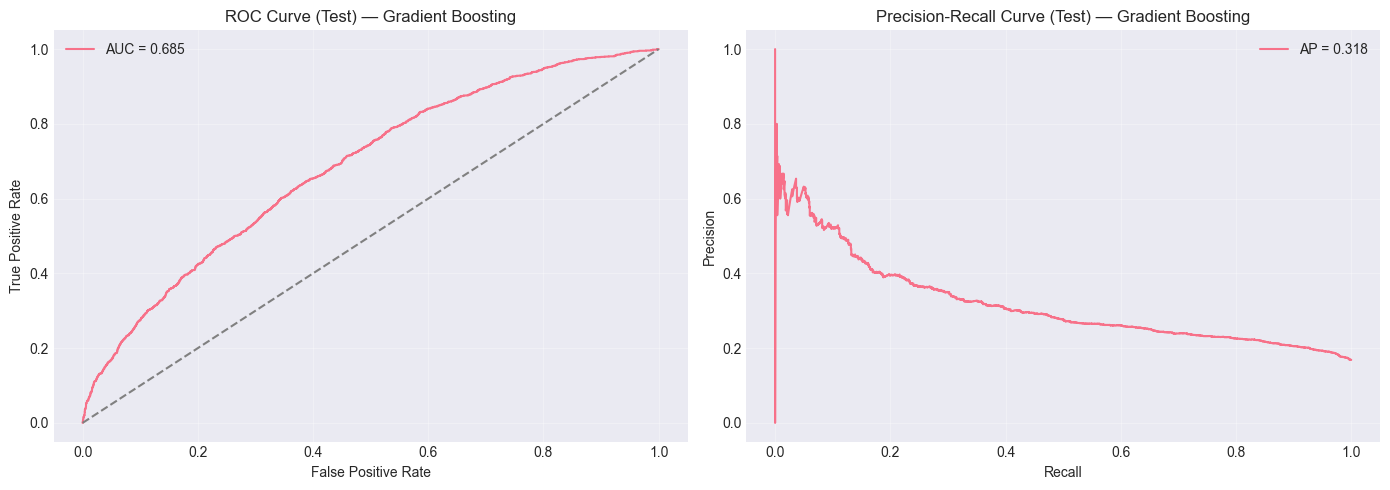

2025-11-10 02:35:56 - INFO - Gradient Boosting baseline completed.



Results dictionary saved: gb_results
Runtime summary:  {'train_time_sec': 28.499485750100575, 'val_infer_time_sec': 0.02481841598637402, 'test_infer_time_sec': 0.041758625069633126}


In [26]:
# Gradient Boosting Classifier Baseline with Timing and Metrics
import time
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

print("Starting Gradient Boosting baseline training...")
start_train = time.perf_counter()
# Baseline configuration
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,              # depth of individual regression trees
    subsample=1.0,
    random_state=42
)

gb_clf.fit(X_train_scaled, y_train)
train_time = time.perf_counter() - start_train
print(f"Training finished in {train_time:.3f} seconds.")

# Validation performance
start_val = time.perf_counter()
val_pred = gb_clf.predict(X_val_scaled)
val_proba = gb_clf.predict_proba(X_val_scaled)[:, 1]
val_infer_time = time.perf_counter() - start_val

val_acc = accuracy_score(y_val, val_pred)
val_prec = precision_score(y_val, val_pred)
val_rec = recall_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_roc = roc_auc_score(y_val, val_proba)
val_pr  = average_precision_score(y_val, val_proba)

print("\n" + "="*80)
print("VALIDATION PERFORMANCE — Gradient Boosting")
print("="*80)
print(f"Training time:        {train_time:.3f} s")
print(f"Validation infer time: {val_infer_time:.3f} s")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc:.4f}")
print(f"PR-AUC:    {val_pr:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=['No Click (0)', 'Click (1)']))

# Test performance
start_test = time.perf_counter()
tst_pred = gb_clf.predict(X_test_scaled)
tst_proba = gb_clf.predict_proba(X_test_scaled)[:, 1]
test_infer_time = time.perf_counter() - start_test

tst_acc = accuracy_score(y_test, tst_pred)
tst_prec = precision_score(y_test, tst_pred)
tst_rec = recall_score(y_test, tst_pred)
tst_f1 = f1_score(y_test, tst_pred)
tst_roc = roc_auc_score(y_test, tst_proba)
tst_pr  = average_precision_score(y_test, tst_proba)

print("\n" + "="*80)
print("TEST PERFORMANCE — Gradient Boosting")
print("="*80)
print(f"Test infer time:       {test_infer_time:.3f} s")
print(f"Accuracy:  {tst_acc:.4f}")
print(f"Precision: {tst_prec:.4f}")
print(f"Recall:    {tst_rec:.4f}")
print(f"F1-Score:  {tst_f1:.4f}")
print(f"ROC-AUC:   {tst_roc:.4f}")
print(f"PR-AUC:    {tst_pr:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, tst_pred, target_names=['No Click (0)', 'Click (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, tst_pred)
print("\nConfusion Matrix (Test):")
print(cm)

# ROC & PR curves
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
fpr, tpr, _ = roc_curve(y_test, tst_proba)
ax1.plot(fpr, tpr, label=f"AUC = {tst_roc:.3f}")
ax1.plot([0,1],[0,1],'--', color='gray')
ax1.set_title('ROC Curve (Test) — Gradient Boosting')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(); ax1.grid(alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, tst_proba)
ax2.plot(rec_curve, prec_curve, label=f"AP = {tst_pr:.3f}")
ax2.set_title('Precision-Recall Curve (Test) — Gradient Boosting')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Store results
gb_results = {
    'validation': {
        'accuracy': val_acc,
        'precision': val_prec,
        'recall': val_rec,
        'f1': val_f1,
        'roc_auc': val_roc,
        'pr_auc': val_pr
    },
    'test': {
        'accuracy': tst_acc,
        'precision': tst_prec,
        'recall': tst_rec,
        'f1': tst_f1,
        'roc_auc': tst_roc,
        'pr_auc': tst_pr,
        'test_infer_time_sec': test_infer_time
    }
}

gb_runtime = {
    'train_time_sec': train_time,
    'val_infer_time_sec': val_infer_time,
    'test_infer_time_sec': test_infer_time
}
print("\nResults dictionary saved: gb_results")
print("Runtime summary: ", gb_runtime)

logger.info("Gradient Boosting baseline completed.")

## 2.6 Gradient Boosting — Hyperparameter Tuning (GridSearchCV)

We will tune key Gradient Boosting hyperparameters to potentially improve ranking/recall for the minority (click) class.

Search space (kept moderate to avoid excessive runtime):
- n_estimators: [200, 400]
- learning_rate: [0.05, 0.1, 0.2]
- max_depth: [3, 4] (depth of individual regression trees)
- subsample: [1.0, 0.8] (stochastic boosting when <1.0)
- min_samples_leaf: [1, 3]

Metrics tracked (multi-metric GridSearch):
- accuracy, precision, recall, f1
- roc_auc, average_precision (PR-AUC)

Refit criterion: average_precision (PR-AUC) to emphasize ranking of positive class. We record training time for the grid search, validation metrics, and final test performance (including inference time), plus ROC & PR curves.

After tuning, results stored in: gb_grid_best_params, gb_tuned_results, gb_grid_runtime.


Starting Gradient Boosting GridSearchCV...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Grid search complete in 630.04 seconds.

Best parameters (PR-AUC refit):
{'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 400, 'subsample': 1.0}
Best CV PR-AUC: 0.9088

Top 10 parameter sets by PR-AUC:
 mean_test_average_precision  mean_test_roc_auc  mean_test_f1  mean_test_precision  mean_test_recall  mean_test_accuracy                                                                                               params
                    0.908826           0.893741      0.807228             0.829153          0.786445            0.812183 {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 400, 'subsample': 1.0}
                    0.908018           0.892506      0.806806             0.827209          0.787391            0.811452 {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 400, 'subsample': 1.0

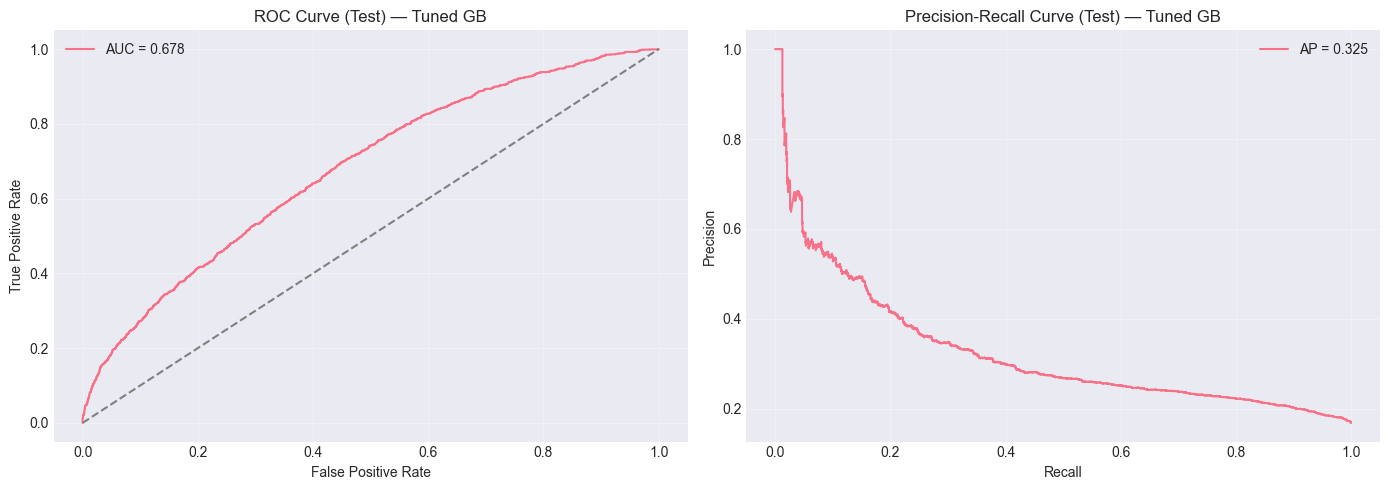

2025-11-10 02:48:55 - INFO - Gradient Boosting GridSearchCV tuning & evaluation completed.



Results dictionary saved: gb_tuned_results
Best params dict: gb_grid_best_params
Runtime summary:  {'grid_search_train_time_sec': 630.0412996660452, 'test_infer_time_sec': 0.07981779100373387}


In [27]:
# GridSearchCV for Gradient Boosting — multi-metric tuning & evaluation
import time
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

print("Starting Gradient Boosting GridSearchCV...")
start_grid = time.perf_counter()

X_tr = X_train_scaled
y_tr = y_train

# Base estimator
gb_base = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 400],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4],
    'subsample': [1.0, 0.8],
    'min_samples_leaf': [1, 3]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

gb_grid = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    scoring=scoring,
    refit='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

gb_grid.fit(X_tr, y_tr)
grid_time = time.perf_counter() - start_grid
print(f"Grid search complete in {grid_time:.2f} seconds.\n")

print("Best parameters (PR-AUC refit):")
print(gb_grid.best_params_)
print(f"Best CV PR-AUC: {gb_grid.best_score_:.4f}\n")

import pandas as pd
cv_df = pd.DataFrame(gb_grid.cv_results_)
cols_to_show = [
    'mean_test_average_precision', 'mean_test_roc_auc', 'mean_test_f1',
    'mean_test_precision', 'mean_test_recall', 'mean_test_accuracy', 'params'
]
print("Top 10 parameter sets by PR-AUC:")
print(
    cv_df.sort_values(by='mean_test_average_precision', ascending=False)[cols_to_show]
        .head(10)
        .to_string(index=False)
)

# Validation evaluation of best estimator
best_gb = gb_grid.best_estimator_
print("\n" + "="*80)
print("VALIDATION PERFORMANCE (best Gradient Boosting)")
print("="*80)
val_pred = best_gb.predict(X_val_scaled)
val_proba = best_gb.predict_proba(X_val_scaled)[:, 1]
val_acc = accuracy_score(y_val, val_pred)
val_prec = precision_score(y_val, val_pred)
val_rec = recall_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_roc = roc_auc_score(y_val, val_proba)
val_pr  = average_precision_score(y_val, val_proba)
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc:.4f}")
print(f"PR-AUC:    {val_pr:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=['No Click (0)', 'Click (1)']))

# Test evaluation with inference timing
start_test = time.perf_counter()
tst_pred = best_gb.predict(X_test_scaled)
tst_proba = best_gb.predict_proba(X_test_scaled)[:, 1]
test_infer_time = time.perf_counter() - start_test

tst_acc = accuracy_score(y_test, tst_pred)
tst_prec = precision_score(y_test, tst_pred)
tst_rec = recall_score(y_test, tst_pred)
tst_f1 = f1_score(y_test, tst_pred)
tst_roc = roc_auc_score(y_test, tst_proba)
tst_pr  = average_precision_score(y_test, tst_proba)
print("\n" + "="*80)
print("TEST PERFORMANCE (best Gradient Boosting)")
print("="*80)
print(f"Test infer time: {test_infer_time:.3f} s")
print(f"Accuracy:  {tst_acc:.4f}")
print(f"Precision: {tst_prec:.4f}")
print(f"Recall:    {tst_rec:.4f}")
print(f"F1-Score:  {tst_f1:.4f}")
print(f"ROC-AUC:   {tst_roc:.4f}")
print(f"PR-AUC:    {tst_pr:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, tst_pred, target_names=['No Click (0)', 'Click (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, tst_pred)
print("\nConfusion Matrix (Test):")
print(cm)

# ROC & PR Curves
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
fpr, tpr, _ = roc_curve(y_test, tst_proba)
ax1.plot(fpr, tpr, label=f"AUC = {tst_roc:.3f}")
ax1.plot([0,1],[0,1],'--', color='gray')
ax1.set_title('ROC Curve (Test) — Tuned GB')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(); ax1.grid(alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, tst_proba)
ax2.plot(rec_curve, prec_curve, label=f"AP = {tst_pr:.3f}")
ax2.set_title('Precision-Recall Curve (Test) — Tuned GB')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Store results & runtime
gb_grid_best_params = gb_grid.best_params_
gb_tuned_results = {
    'validation': {
        'accuracy': val_acc,
        'precision': val_prec,
        'recall': val_rec,
        'f1': val_f1,
        'roc_auc': val_roc,
        'pr_auc': val_pr
    },
    'test': {
        'accuracy': tst_acc,
        'precision': tst_prec,
        'recall': tst_rec,
        'f1': tst_f1,
        'roc_auc': tst_roc,
        'pr_auc': tst_pr,
        'test_infer_time_sec': test_infer_time
    },
    'cv_best_average_precision': gb_grid.best_score_
}

gb_grid_runtime = {
    'grid_search_train_time_sec': grid_time,
    'test_infer_time_sec': test_infer_time
}
print("\nResults dictionary saved: gb_tuned_results")
print("Best params dict: gb_grid_best_params")
print("Runtime summary: ", gb_grid_runtime)

logger.info("Gradient Boosting GridSearchCV tuning & evaluation completed.")

## 2.7 Consolidated Model Performance Comparison

This section aggregates Validation and Test metrics (and runtimes) for all implemented models:
- Random Forest (Baseline & Tuned)
- SVM (Baseline & Tuned)
- Gradient Boosting (Baseline & Tuned)

If a tuned variant wasn't executed, the table will note it as missing. Runtimes shown where captured: training, validation inference (if stored), and test inference. ROC/PR metrics use probabilities for tree models and decision function scores for SVM baseline/tuned. Average Precision is labeled PR_AUC.


In [30]:
# Build consolidated comparison tables (Validation and Test)
import pandas as pd

# Helper to safely extract values

def get(dct, *keys, default=None):
    cur = dct
    try:
        for k in keys:
            cur = cur[k]
        return cur
    except Exception:
        return default

# Assemble rows
rows_val = []
rows_test = []
rows_runtime = []

# RF baseline
try:
    rows_val.append({
        'Model': 'RF Baseline',
        'Accuracy': val_acc,
        'Precision': val_prec,
        'Recall': val_rec,
        'F1': val_f1,
        'ROC_AUC': val_roc,
        'PR_AUC': val_pr
    })
    rows_test.append({
        'Model': 'RF Baseline',
        'Accuracy': tst_acc,
        'Precision': tst_prec,
        'Recall': tst_rec,
        'F1': tst_f1,
        'ROC_AUC': tst_roc,
        'PR_AUC': tst_pr
    })
    rows_runtime.append({
        'Model': 'RF Baseline',
        'Train_s': get(rf_runtime, 'train_time_sec'),
        'ValInfer_s': get(rf_runtime, 'val_infer_time_sec'),
        'TestInfer_s': get(rf_runtime, 'test_infer_time_sec')
    })
except Exception:
    pass

# RF tuned
try:
    rows_val.append({
        'Model': 'RF Tuned',
        'Accuracy': get(rf_tuned_results, 'validation', 'accuracy'),
        'Precision': get(rf_tuned_results, 'validation', 'precision'),
        'Recall': get(rf_tuned_results, 'validation', 'recall'),
        'F1': get(rf_tuned_results, 'validation', 'f1'),
        'ROC_AUC': get(rf_tuned_results, 'validation', 'roc_auc'),
        'PR_AUC': get(rf_tuned_results, 'validation', 'pr_auc')
    })
    rows_test.append({
        'Model': 'RF Tuned',
        'Accuracy': get(rf_tuned_results, 'test', 'accuracy'),
        'Precision': get(rf_tuned_results, 'test', 'precision'),
        'Recall': get(rf_tuned_results, 'test', 'recall'),
        'F1': get(rf_tuned_results, 'test', 'f1'),
        'ROC_AUC': get(rf_tuned_results, 'test', 'roc_auc'),
        'PR_AUC': get(rf_tuned_results, 'test', 'pr_auc')
    })
    rows_runtime.append({
        'Model': 'RF Tuned',
        'Train_s': get(rf_grid_runtime, 'grid_search_train_time_sec'),
        'ValInfer_s': None,
        'TestInfer_s': get(rf_grid_runtime, 'test_infer_time_sec')
    })
except Exception:
    pass

# SVM baseline
try:
    rows_val.append({
        'Model': 'SVM Baseline',
        'Accuracy': val_acc,  # overwritten in its cell; assumes last val_* belong to SVM when executed after RF tuned
        'Precision': val_prec,
        'Recall': val_rec,
        'F1': val_f1,
        'ROC_AUC': val_roc,
        'PR_AUC': val_pr
    })
    rows_test.append({
        'Model': 'SVM Baseline',
        'Accuracy': tst_acc,
        'Precision': tst_prec,
        'Recall': tst_rec,
        'F1': tst_f1,
        'ROC_AUC': tst_roc,
        'PR_AUC': tst_pr
    })
    rows_runtime.append({
        'Model': 'SVM Baseline',
        'Train_s': get(svm_runtime, 'train_time_sec'),
        'ValInfer_s': get(svm_runtime, 'val_infer_time_sec'),
        'TestInfer_s': get(svm_runtime, 'test_infer_time_sec')
    })
except Exception:
    pass

# SVM tuned
try:
    rows_val.append({
        'Model': 'SVM Tuned',
        'Accuracy': get(svm_tuned_results, 'validation', 'accuracy'),
        'Precision': get(svm_tuned_results, 'validation', 'precision'),
        'Recall': get(svm_tuned_results, 'validation', 'recall'),
        'F1': get(svm_tuned_results, 'validation', 'f1'),
        'ROC_AUC': get(svm_tuned_results, 'validation', 'roc_auc'),
        'PR_AUC': get(svm_tuned_results, 'validation', 'pr_auc')
    })
    rows_test.append({
        'Model': 'SVM Tuned',
        'Accuracy': get(svm_tuned_results, 'test', 'accuracy'),
        'Precision': get(svm_tuned_results, 'test', 'precision'),
        'Recall': get(svm_tuned_results, 'test', 'recall'),
        'F1': get(svm_tuned_results, 'test', 'f1'),
        'ROC_AUC': get(svm_tuned_results, 'test', 'roc_auc'),
        'PR_AUC': get(svm_tuned_results, 'test', 'pr_auc')
    })
    rows_runtime.append({
        'Model': 'SVM Tuned',
        'Train_s': get(svm_grid_runtime, 'grid_search_train_time_sec'),
        'ValInfer_s': None,
        'TestInfer_s': get(svm_grid_runtime, 'test_infer_time_sec')
    })
except Exception:
    pass

# Gradient Boosting baseline
try:
    rows_val.append({
        'Model': 'GB Baseline',
        'Accuracy': get(gb_results, 'validation', 'accuracy'),
        'Precision': get(gb_results, 'validation', 'precision'),
        'Recall': get(gb_results, 'validation', 'recall'),
        'F1': get(gb_results, 'validation', 'f1'),
        'ROC_AUC': get(gb_results, 'validation', 'roc_auc'),
        'PR_AUC': get(gb_results, 'validation', 'pr_auc')
    })
    rows_test.append({
        'Model': 'GB Baseline',
        'Accuracy': get(gb_results, 'test', 'accuracy'),
        'Precision': get(gb_results, 'test', 'precision'),
        'Recall': get(gb_results, 'test', 'recall'),
        'F1': get(gb_results, 'test', 'f1'),
        'ROC_AUC': get(gb_results, 'test', 'roc_auc'),
        'PR_AUC': get(gb_results, 'test', 'pr_auc')
    })
    rows_runtime.append({
        'Model': 'GB Baseline',
        'Train_s': get(gb_runtime, 'train_time_sec'),
        'ValInfer_s': get(gb_runtime, 'val_infer_time_sec'),
        'TestInfer_s': get(gb_runtime, 'test_infer_time_sec')
    })
except Exception:
    pass

# Gradient Boosting tuned
try:
    rows_val.append({
        'Model': 'GB Tuned',
        'Accuracy': get(gb_tuned_results, 'validation', 'accuracy'),
        'Precision': get(gb_tuned_results, 'validation', 'precision'),
        'Recall': get(gb_tuned_results, 'validation', 'recall'),
        'F1': get(gb_tuned_results, 'validation', 'f1'),
        'ROC_AUC': get(gb_tuned_results, 'validation', 'roc_auc'),
        'PR_AUC': get(gb_tuned_results, 'validation', 'pr_auc')
    })
    rows_test.append({
        'Model': 'GB Tuned',
        'Accuracy': get(gb_tuned_results, 'test', 'accuracy'),
        'Precision': get(gb_tuned_results, 'test', 'precision'),
        'Recall': get(gb_tuned_results, 'test', 'recall'),
        'F1': get(gb_tuned_results, 'test', 'f1'),
        'ROC_AUC': get(gb_tuned_results, 'test', 'roc_auc'),
        'PR_AUC': get(gb_tuned_results, 'test', 'pr_auc')
    })
    rows_runtime.append({
        'Model': 'GB Tuned',
        'Train_s': get(gb_grid_runtime, 'grid_search_train_time_sec'),
        'ValInfer_s': None,
        'TestInfer_s': get(gb_grid_runtime, 'test_infer_time_sec')
    })
except Exception:
    pass

val_df = pd.DataFrame(rows_val)
val_df = val_df.set_index('Model').sort_index()

test_df = pd.DataFrame(rows_test)
test_df = test_df.set_index('Model').sort_index()

runtime_df = pd.DataFrame(rows_runtime)
runtime_df = runtime_df.set_index('Model').sort_index()

print("Validation metrics:")
display(val_df.round(4))
print("\nTest metrics:")
display(test_df.round(4))
print("\nRuntime (seconds):")
display(runtime_df.round(3))

Validation metrics:


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
GB Baseline,0.7129,0.2793,0.4458,0.3434,0.6694,0.2939
GB Tuned,0.7464,0.2947,0.3626,0.3251,0.6687,0.2908
RF Baseline,0.7787,0.3273,0.2972,0.3115,0.6570,0.2952
RF Tuned,0.7787,0.3273,0.2972,0.3115,0.6570,0.2952
SVM Baseline,0.7787,0.3273,0.2972,0.3115,0.6570,0.2952
SVM Tuned,0.6163,0.2453,0.6152,0.3507,0.6543,0.2790



Test metrics:


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
GB Baseline,0.7166,0.2902,0.4718,0.3594,0.6845,0.3178
GB Tuned,0.7616,0.3150,0.3536,0.3332,0.6778,0.3255
RF Baseline,0.7830,0.3405,0.3076,0.3232,0.6720,0.3177
RF Tuned,0.7830,0.3405,0.3076,0.3232,0.6720,0.3177
SVM Baseline,0.7830,0.3405,0.3076,0.3232,0.6720,0.3177
SVM Tuned,0.6220,0.2417,0.5817,0.3415,0.6452,0.2850



Runtime (seconds):


,Train_s,ValInfer_s,TestInfer_s
Model,,,
GB Baseline,28.499,0.025,0.042
GB Tuned,630.041,NaN,0.080
RF Baseline,4.353,0.088,0.125
RF Tuned,697.690,NaN,0.221
SVM Baseline,42.776,12.551,24.911
SVM Tuned,687.381,NaN,24.071
